# 09B — Role-Invariant XGBoost Challenge

## 这一步只检查一个假设

09的完整XGBoost在大选前很好，但在2024年大选后早期出现系统性错误：

- 大选前Macro-F1约为0.77–0.86；
- 大选后早期Macro-F1降到0.421；
- 大选后早期ROC-AUC只有0.338。

一种可能原因是模型记住了固定政党名称：

```text
Conservative → 执政党
Labour → 主要反对党
```

但2024年大选后两个政党的制度角色交换了。

本Notebook删除固定政党名称，只让XGBoost读取：

- governing party / main opposition / smaller opposition；
- 政策对象是否由政府背书；
- motion type、motion family和policy domain；
- 投票前可获得的程序字段。

然后比较两个新候选：

1. `role_only_xgboost`：只学习制度角色和议案语境；
2. `role_prior_blend_50_50`：角色模型概率与最近100票Party Prior各占50%。

50/50权重在查看结果前固定，不进行大量比例搜索。

**本Notebook不读取最终Test、不调用API、不运行LLM。**


## 为什么还要保留最近100票先验

删除政党名称后，Green和Liberal Democrat如果同属`smaller_opposition`，角色模型可能给它们非常相近的概率。

近期Party Prior虽然不理解议案，但可以补充“这个政党最近总体更经常支持还是反对”的信息。

融合后的含义是：

```text
最终概率 = 50% × 角色模型概率 + 50% × 最近100票支持率
```

它不是让先验覆盖模型，而是让制度规律和近期政党倾向各贡献一半。


In [1]:
# 导入免费角色模型回测需要的库；这里不会调用API或读取Test
import json
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid")

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "processed" / "model_v2"
INPUT_DIR = BASE_DIR / "processed" / "temporal_model_challenge_v1"
OUTPUT_DIR = BASE_DIR / "processed" / "role_invariant_challenge_v2"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "model_train_v2.csv"
VALIDATION_PATH = DATA_DIR / "model_validation_v2.csv"
EXISTING_PREDICTIONS_PATH = INPUT_DIR / "temporal_model_predictions.csv"

TARGET = "target_binary_support"
RANDOM_STATE = 42
TIME_DECAY_HALF_LIFE_YEARS = 2.0
CLASSIFICATION_THRESHOLD = 0.50
BLEND_ROLE_WEIGHT = 0.50
BLEND_PRIOR_WEIGHT = 0.50

# 这些通过门槛在查看09B结果前固定
MIN_POST_IMPROVEMENT = 0.03
MIN_MEAN_FOLD_MACRO_F1 = 0.60
MIN_WORST_FOLD_MACRO_F1 = 0.50
MIN_POST_WORST_PARTY_MACRO_F1 = 0.50

print("Notebook version: 09b-role-invariant-xgboost-v2")
print("API calls: 0")
print("LLM calls: 0")
print("Test loaded: False")
print("Output directory:", OUTPUT_DIR)


Notebook version: 09b-role-invariant-xgboost-v2
API calls: 0
LLM calls: 0
Test loaded: False
Output directory: /Users/oooo1/01Course/2_70202Applying/reorganised/processed/role_invariant_challenge_v2


## 1. 读取开发数据和09的既有预测

09已经完成六个时间窗口的严格walk-forward回测。这里复用以下旧模型结果作为比较对象：

- 完整时间衰减XGBoost；
- 最近100票Party Prior；
- 全历史Party Prior。

只有两个新的角色模型会重新计算。


In [2]:
# 只读取Train、Validation和09输出，不定义最终Test路径
train = pd.read_csv(TRAIN_PATH)
validation = pd.read_csv(VALIDATION_PATH)
existing_predictions = pd.read_csv(EXISTING_PREDICTIONS_PATH)

for frame in (train, validation):
    frame["motion_date"] = pd.to_datetime(frame["motion_date"])
    frame[TARGET] = pd.to_numeric(frame[TARGET], errors="raise").astype(int)

existing_predictions["motion_date"] = pd.to_datetime(
    existing_predictions["motion_date"]
)
existing_predictions[TARGET] = pd.to_numeric(
    existing_predictions[TARGET], errors="raise"
).astype(int)

assert not set(train["division_key"]) & set(validation["division_key"])

development = (
    pd.concat([train, validation], ignore_index=True)
    .sort_values(["motion_date", "division_key", "party"])
    .reset_index(drop=True)
)

required_existing_models = {
    "time_decay_xgboost",
    "rolling_100_party_prior",
    "expanding_party_prior",
}
missing_existing_models = required_existing_models - set(
    existing_predictions["model"].unique()
)
if missing_existing_models:
    raise ValueError(
        f"09预测文件缺少模型：{sorted(missing_existing_models)}"
    )

print("Development rows:", len(development))
print("Development divisions:", development["division_key"].nunique())
print("Existing prediction rows:", len(existing_predictions))
print("Existing folds:", sorted(existing_predictions["fold"].unique()))


Development rows: 3392
Development divisions: 939
Existing prediction rows: 16272
Existing folds: ['2021', '2022', '2023', '2024_early_post', '2024_late_post', '2024_pre']


## 2. 沿用完全相同的六个时间窗口

改变评测时间会导致09与09B不可比较，因此这里沿用：

- 2021；
- 2022；
- 2023；
- 2024大选前；
- 2024大选后早期；
- 2024大选后晚期。

每个窗口只能使用窗口开始日期以前的标签。


In [3]:
# 时间范围与09完全一致，不能根据09B成绩重新切分
FOLDS = [
    {"fold": "2021", "start": "2021-01-01", "end": "2022-01-01", "era": "pre_election"},
    {"fold": "2022", "start": "2022-01-01", "end": "2023-01-01", "era": "pre_election"},
    {"fold": "2023", "start": "2023-01-01", "end": "2024-01-01", "era": "pre_election"},
    {"fold": "2024_pre", "start": "2024-01-01", "end": "2024-07-05", "era": "pre_election"},
    {"fold": "2024_early_post", "start": "2024-07-05", "end": "2024-11-06", "era": "post_election"},
    {"fold": "2024_late_post", "start": "2024-11-06", "end": "2025-01-01", "era": "post_election"},
]

for fold in FOLDS:
    fold["start"] = pd.Timestamp(fold["start"])
    fold["end"] = pd.Timestamp(fold["end"])

expected_folds = {fold["fold"] for fold in FOLDS}
assert set(existing_predictions["fold"].unique()) == expected_folds


## 3. 构造与政党名称无关的角色特征

有意删除：

- `party`；
- `government_party`；
- `main_opposition_party`。

因为这些字段包含固定政党名称，容易让模型记住旧政府。

新增`role_backing_interaction`，例如：

```text
governing_party__True
main_opposition__True
smaller_opposition__False
```

它帮助树模型直接学习“某类角色面对政府背书政策对象时通常如何反应”。


In [4]:
# 角色类别不包含任何固定政党名称
ROLE_CATEGORICAL_FEATURES = [
    "party_role",
    "final_object_government_backed",
    "government_backing_known",
    "motion_type",
    "motion_family",
    "policy_domain_primary",
    "role_backing_interaction",
]

# 数值字段均在当前投票发生前可以获得
ROLE_NUMERIC_FEATURES = [
    "motion_month",
    "total_possible_members",
    "is_governing_party",
    "is_main_opposition",
    "is_opposition_day",
    "is_amendment",
    "is_new_clause",
    "is_financial_motion",
    "policy_domain_count",
]

FORBIDDEN_FEATURES = {
    "party",
    "government_party",
    "main_opposition_party",
    TARGET,
    "party_result",
    "party_for",
    "party_against",
    "party_for_percentage",
    "party_majority",
    "party_absent",
    "total_for",
    "total_against",
    "total_result",
    "total_majority",
    "target_policy_result",
    "target_policy_stance",
    "target_policy_stance_score",
    "target_ordinal_provisional",
}

development["role_backing_interaction"] = (
    development["party_role"].fillna("unknown").astype(str)
    + "__"
    + development["final_object_government_backed"]
        .fillna("unknown").astype(str)
)

selected_role_features = set(
    ROLE_CATEGORICAL_FEATURES + ROLE_NUMERIC_FEATURES
)
assert not selected_role_features & FORBIDDEN_FEATURES

missing_role_features = selected_role_features - set(development.columns)
assert not missing_role_features, (
    f"缺少角色模型字段：{sorted(missing_role_features)}"
)

for column in ROLE_CATEGORICAL_FEATURES:
    development[column] = (
        development[column].fillna("__missing__").astype(str)
    )

for column in ROLE_NUMERIC_FEATURES:
    development[column] = pd.to_numeric(
        development[column], errors="coerce"
    )

print("Role categorical features:", len(ROLE_CATEGORICAL_FEATURES))
print("Role numeric features:", len(ROLE_NUMERIC_FEATURES))
print("Fixed party-name features used: 0")


Role categorical features: 7
Role numeric features: 9
Fixed party-name features used: 0


## 4. 使用与09相同的时间衰减和XGBoost参数

如果同时改变字段、半衰期、树深度和学习率，就无法知道改善来自哪里。

因此09B只改变一件事：删除政党名称并加入角色—政府背书交互。其他设置全部与09一致：

- 两年半衰期；
- 深度3；
- 学习率0.03；
- 300棵树；
- 较强正则化。


In [5]:
def time_decay_weights(history, reference_date):
    # 两年前记录权重减半，四年前减为四分之一
    age_days = (
        reference_date - history["motion_date"]
    ).dt.days.clip(lower=0)
    age_years = age_days / 365.25
    return np.power(0.5, age_years / TIME_DECAY_HALF_LIFE_YEARS)


def make_role_preprocessor():
    # 类别字段独热编码，数值字段补缺并缩放
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("one_hot", OneHotEncoder(handle_unknown="ignore")),
    ])
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scale", StandardScaler(with_mean=False)),
    ])
    return ColumnTransformer([
        ("categorical", categorical_pipeline, ROLE_CATEGORICAL_FEATURES),
        ("numeric", numeric_pipeline, ROLE_NUMERIC_FEATURES),
    ], remainder="drop")


def fit_role_xgboost(history, evaluation, reference_date):
    # 预处理器只在当前fold的历史数据上拟合
    preprocessor = make_role_preprocessor()
    train_matrix = preprocessor.fit_transform(history)
    evaluation_matrix = preprocessor.transform(evaluation)
    sample_weights = time_decay_weights(history, reference_date)

    model = XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.03,
        min_child_weight=10,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=5.0,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(
        train_matrix,
        history[TARGET],
        sample_weight=sample_weights,
    )
    probabilities = model.predict_proba(evaluation_matrix)[:, 1]
    return probabilities


## 5. 运行角色型walk-forward回测

每个fold重新训练一次，只预测未来时间窗口。

运行后再与09保存的最近100票概率合并，计算固定50/50融合概率。


In [6]:
# 保存角色模型逐行概率，随后再与09的近期先验进行融合
role_prediction_parts = []
fit_time_rows = []

for fold in FOLDS:
    print(f"Running role model fold: {fold['fold']}")
    history = development[
        development["motion_date"] < fold["start"]
    ].copy()
    evaluation = development[
        (development["motion_date"] >= fold["start"])
        & (development["motion_date"] < fold["end"])
    ].copy()

    assert not set(history["division_key"]) & set(evaluation["division_key"])

    started = time.perf_counter()
    probabilities = fit_role_xgboost(
        history, evaluation, fold["start"]
    )
    fit_time_rows.append({
        "fold": fold["fold"],
        "model": "role_only_xgboost",
        "fit_seconds": time.perf_counter() - started,
    })

    part = evaluation[[
        "row_id",
        "division_key",
        "motion_date",
        "party",
        "motion_title_clean",
        "motion_family",
        "policy_domain_primary",
        TARGET,
    ]].copy()
    part["fold"] = fold["fold"]
    part["era"] = fold["era"]
    part["model"] = "role_only_xgboost"
    part["probability"] = probabilities
    part["prediction"] = (
        part["probability"] >= CLASSIFICATION_THRESHOLD
    ).astype(int)
    role_prediction_parts.append(part)

role_predictions = pd.concat(role_prediction_parts, ignore_index=True)

# 从09读取完全相同行的最近100票先验概率
rolling_prior = existing_predictions[
    existing_predictions["model"] == "rolling_100_party_prior"
][["row_id", "fold", "probability"]].rename(
    columns={"probability": "rolling_prior_probability"}
)

blend_predictions = role_predictions.merge(
    rolling_prior,
    on=["row_id", "fold"],
    how="left",
    validate="one_to_one",
)
if blend_predictions["rolling_prior_probability"].isna().any():
    raise ValueError("部分角色模型记录无法匹配09的最近100票概率。")

blend_predictions["model"] = "role_prior_blend_50_50"
blend_predictions["probability"] = (
    BLEND_ROLE_WEIGHT * blend_predictions["probability"]
    + BLEND_PRIOR_WEIGHT
    * blend_predictions["rolling_prior_probability"]
)
blend_predictions["prediction"] = (
    blend_predictions["probability"] >= CLASSIFICATION_THRESHOLD
).astype(int)
blend_predictions = blend_predictions.drop(
    columns=["rolling_prior_probability"]
)

role_predictions.to_csv(
    OUTPUT_DIR / "role_only_predictions_v2.csv", index=False
)
blend_predictions.to_csv(
    OUTPUT_DIR / "role_prior_blend_predictions_v2.csv", index=False
)
pd.DataFrame(fit_time_rows).to_csv(
    OUTPUT_DIR / "role_model_fit_times_v2.csv", index=False
)

print("Role-only predictions:", len(role_predictions))
print("Blend predictions:", len(blend_predictions))


Running role model fold: 2021
Running role model fold: 2022
Running role model fold: 2023
Running role model fold: 2024_pre
Running role model fold: 2024_early_post
Running role model fold: 2024_late_post
Role-only predictions: 2034
Blend predictions: 2034


## 6. 使用同一批行比较新旧模型

比较对象固定为：

- `time_decay_xgboost`：09完整模型；
- `rolling_100_party_prior`：当前最稳定的简单基准；
- `expanding_party_prior`：全历史简单基准；
- `role_only_xgboost`：新角色模型；
- `role_prior_blend_50_50`：新角色模型与近期先验融合。


In [7]:
comparison_existing = existing_predictions[
    existing_predictions["model"].isin(required_existing_models)
].copy()

comparison_predictions = pd.concat([
    comparison_existing,
    role_predictions,
    blend_predictions,
], ignore_index=True)

# 每个模型必须覆盖完全相同的评测行
coverage_check = comparison_predictions.groupby("model").agg(
    rows=("row_id", "size"),
    unique_rows=("row_id", "nunique"),
    folds=("fold", "nunique"),
)
assert coverage_check["rows"].nunique() == 1
assert coverage_check["unique_rows"].nunique() == 1
assert (coverage_check["folds"] == len(FOLDS)).all()

comparison_predictions.to_csv(
    OUTPUT_DIR / "role_model_comparison_predictions_v2.csv",
    index=False,
)
display(coverage_check)


,rows,unique_rows,folds
model,,,
expanding_party_prior,2034,2034,6
role_only_xgboost,2034,2034,6
role_prior_blend_50_50,2034,2034,6
rolling_100_party_prior,2034,2034,6
time_decay_xgboost,2034,2034,6


## 7. 评价整体、各时间窗口和大选后各政党

这次最重要的是：

- `post_election_macro_f1`：大选后整体表现；
- `post_worst_party_macro_f1`：大选后表现最差的政党；
- `worst_fold_macro_f1`：最差时间窗口；
- `mean_fold_macro_f1`：六个时间窗口的平均稳定性。

不能再用大量大选前数据掩盖大选后失败。


In [8]:
def safe_roc_auc(y_true, probabilities):
    # 单一类别分组无法计算ROC-AUC
    if pd.Series(y_true).nunique() < 2:
        return np.nan
    return roc_auc_score(y_true, probabilities)


def evaluate_probabilities(y_true, probabilities):
    # 固定0.50阈值，不针对每个时期单独调节
    y_true = np.asarray(y_true, dtype=int)
    probabilities = np.asarray(probabilities, dtype=float)
    predictions = (
        probabilities >= CLASSIFICATION_THRESHOLD
    ).astype(int)
    return {
        "rows": len(y_true),
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "macro_f1": f1_score(
            y_true, predictions, average="macro", zero_division=0
        ),
        "support_precision": precision_score(
            y_true, predictions, zero_division=0
        ),
        "support_recall": recall_score(
            y_true, predictions, zero_division=0
        ),
        "roc_auc": safe_roc_auc(y_true, probabilities),
        "brier": brier_score_loss(y_true, probabilities),
    }


def grouped_metrics(frame, group_columns):
    # 对任意模型、时期和政党分组计算统一指标
    rows = []
    for keys, group in frame.groupby(group_columns, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        record = dict(zip(group_columns, keys))
        record.update(evaluate_probabilities(
            group[TARGET], group["probability"]
        ))
        rows.append(record)
    return pd.DataFrame(rows)


aggregate_metrics = grouped_metrics(
    comparison_predictions, ["model"]
)
fold_metrics = grouped_metrics(
    comparison_predictions, ["model", "fold", "era"]
)
party_metrics = grouped_metrics(
    comparison_predictions, ["model", "party"]
)

post_predictions = comparison_predictions[
    comparison_predictions["era"] == "post_election"
]
post_metrics = grouped_metrics(post_predictions, ["model"])
post_party_metrics = grouped_metrics(
    post_predictions, ["model", "party"]
)

fold_summary = fold_metrics.groupby("model").agg(
    mean_fold_macro_f1=("macro_f1", "mean"),
    worst_fold_macro_f1=("macro_f1", "min"),
).reset_index()

post_summary = post_metrics.rename(columns={
    "macro_f1": "post_election_macro_f1",
    "accuracy": "post_election_accuracy",
    "roc_auc": "post_election_roc_auc",
    "brier": "post_election_brier",
})[[
    "model",
    "post_election_macro_f1",
    "post_election_accuracy",
    "post_election_roc_auc",
    "post_election_brier",
]]

post_worst_party = (
    post_party_metrics.groupby("model")["macro_f1"]
    .min()
    .reset_index(name="post_worst_party_macro_f1")
)

early_late = fold_metrics[
    fold_metrics["fold"].isin(["2024_early_post", "2024_late_post"])
][["model", "fold", "macro_f1"]].pivot(
    index="model", columns="fold", values="macro_f1"
).reset_index().rename(columns={
    "2024_early_post": "early_post_macro_f1",
    "2024_late_post": "late_post_macro_f1",
})

model_comparison = (
    aggregate_metrics
    .merge(fold_summary, on="model", how="left")
    .merge(post_summary, on="model", how="left")
    .merge(post_worst_party, on="model", how="left")
    .merge(early_late, on="model", how="left")
    .sort_values(
        ["post_election_macro_f1", "post_worst_party_macro_f1"],
        ascending=False,
    )
    .reset_index(drop=True)
)

model_comparison.to_csv(
    OUTPUT_DIR / "role_model_comparison_v2.csv", index=False
)
fold_metrics.to_csv(
    OUTPUT_DIR / "role_model_fold_metrics_v2.csv", index=False
)
post_party_metrics.to_csv(
    OUTPUT_DIR / "role_model_post_party_metrics_v2.csv", index=False
)

display(model_comparison.round(3))
display(
    fold_metrics.pivot(
        index="model", columns="fold", values="macro_f1"
    ).round(3)
)
display(
    post_party_metrics.pivot(
        index="model", columns="party", values="macro_f1"
    ).round(3)
)


,model,rows,accuracy,balanced_accuracy,macro_f1,support_precision,support_recall,roc_auc,brier,mean_fold_macro_f1,worst_fold_macro_f1,post_election_macro_f1,post_election_accuracy,post_election_roc_auc,post_election_brier,post_worst_party_macro_f1,early_post_macro_f1,late_post_macro_f1
0,role_prior_blend_50_50,2034,0.788,0.760,0.768,0.786,0.891,0.874,0.159,0.727,0.558,0.665,0.678,0.697,0.220,0.418,0.558,0.718
1,role_only_xgboost,2034,0.788,0.774,0.776,0.814,0.842,0.883,0.137,0.721,0.549,0.602,0.603,0.644,0.250,0.336,0.549,0.627
2,expanding_party_prior,2034,0.588,0.522,0.499,0.618,0.833,0.560,0.240,0.497,0.361,0.591,0.631,0.586,0.236,0.344,0.517,0.627
3,rolling_100_party_prior,2034,0.663,0.621,0.622,0.685,0.820,0.628,0.225,0.609,0.517,0.591,0.631,0.625,0.232,0.344,0.517,0.627
4,time_decay_xgboost,2034,0.802,0.795,0.794,0.841,0.830,0.886,0.134,0.718,0.421,0.532,0.533,0.515,0.288,0.298,0.421,0.583


fold,2021,2022,2023,2024_early_post,2024_late_post,2024_pre
model,,,,,,
expanding_party_prior,0.418,0.361,0.397,0.517,0.627,0.661
role_only_xgboost,0.760,0.820,0.861,0.549,0.627,0.710
role_prior_blend_50_50,0.739,0.795,0.836,0.558,0.718,0.717
rolling_100_party_prior,0.607,0.551,0.691,0.517,0.627,0.661
time_decay_xgboost,0.772,0.811,0.861,0.421,0.583,0.860


party,conservative,green,labour,liberal-democrat
model,,,,
expanding_party_prior,0.386,0.411,0.344,0.414
role_only_xgboost,0.732,0.336,0.730,0.539
role_prior_blend_50_50,0.810,0.418,0.629,0.534
rolling_100_party_prior,0.386,0.411,0.344,0.414
time_decay_xgboost,0.570,0.298,0.679,0.548


## 8. 决定角色模型是否值得替换简单基准

新模型必须同时满足：

1. 大选后Macro-F1比最近100票先验至少高0.03；
2. 六个fold平均Macro-F1至少0.60；
3. 最差fold Macro-F1至少0.50；
4. 大选后最差政党Macro-F1至少0.50。

如果两个新模型都失败，就停止继续调模型，采用：

```text
最近100票Party Prior → 基础概率
RAG → 证据检索与解释，不覆盖基础概率
```

然后准备一次最终Test。


In [9]:
BASELINE_MODEL = "rolling_100_party_prior"
NEW_CANDIDATES = ["role_only_xgboost", "role_prior_blend_50_50"]

comparison_indexed = model_comparison.set_index("model")
baseline = comparison_indexed.loc[BASELINE_MODEL]

# 候选首先按大选后表现排序，其次看大选后最差政党
selected_candidate_name = (
    model_comparison[
        model_comparison["model"].isin(NEW_CANDIDATES)
    ]
    .sort_values(
        ["post_election_macro_f1", "post_worst_party_macro_f1"],
        ascending=False,
    )
    .iloc[0]["model"]
)
candidate = comparison_indexed.loc[selected_candidate_name]

acceptance_gates = {
    "post_election_improvement_gate": bool(
        candidate["post_election_macro_f1"]
        >= baseline["post_election_macro_f1"] + MIN_POST_IMPROVEMENT
    ),
    "mean_fold_gate": bool(
        candidate["mean_fold_macro_f1"]
        >= MIN_MEAN_FOLD_MACRO_F1
    ),
    "worst_fold_gate": bool(
        candidate["worst_fold_macro_f1"]
        >= MIN_WORST_FOLD_MACRO_F1
    ),
    "post_worst_party_gate": bool(
        candidate["post_worst_party_macro_f1"]
        >= MIN_POST_WORST_PARTY_MACRO_F1
    ),
}

candidate_passes = all(acceptance_gates.values())
recommended_model = (
    selected_candidate_name
    if candidate_passes
    else BASELINE_MODEL
)

if candidate_passes:
    next_step = (
        "Freeze the passing role model and prepare one final Test run."
    )
else:
    next_step = (
        "Stop model tuning; freeze Rolling-100 Party Prior as the probability "
        "baseline and keep RAG as the explanation layer."
    )

recommendation = {
    "notebook_version": "09b-role-invariant-xgboost-v2",
    "selected_candidate": str(selected_candidate_name),
    "candidate_passes": bool(candidate_passes),
    "recommended_model": str(recommended_model),
    "blend_role_weight": float(BLEND_ROLE_WEIGHT),
    "blend_prior_weight": float(BLEND_PRIOR_WEIGHT),
    "acceptance_gates": acceptance_gates,
    "next_step": next_step,
    "test_loaded": False,
    "api_calls": 0,
}

with (OUTPUT_DIR / "role_model_recommendation_v2.json").open(
    "w", encoding="utf-8"
) as handle:
    json.dump(recommendation, handle, ensure_ascii=False, indent=2)

print("Selected candidate:", selected_candidate_name)
print("Acceptance gates:", acceptance_gates)
print("Recommended model:", recommended_model)
print("Next step:", next_step)


Selected candidate: role_prior_blend_50_50
Acceptance gates: {'post_election_improvement_gate': True, 'mean_fold_gate': True, 'worst_fold_gate': True, 'post_worst_party_gate': False}
Recommended model: rolling_100_party_prior
Next step: Stop model tuning; freeze Rolling-100 Party Prior as the probability baseline and keep RAG as the explanation layer.


## 9. 可视化大选前后差异

左图显示六个时间窗口，右图只比较大选后整体和大选后最差政党。


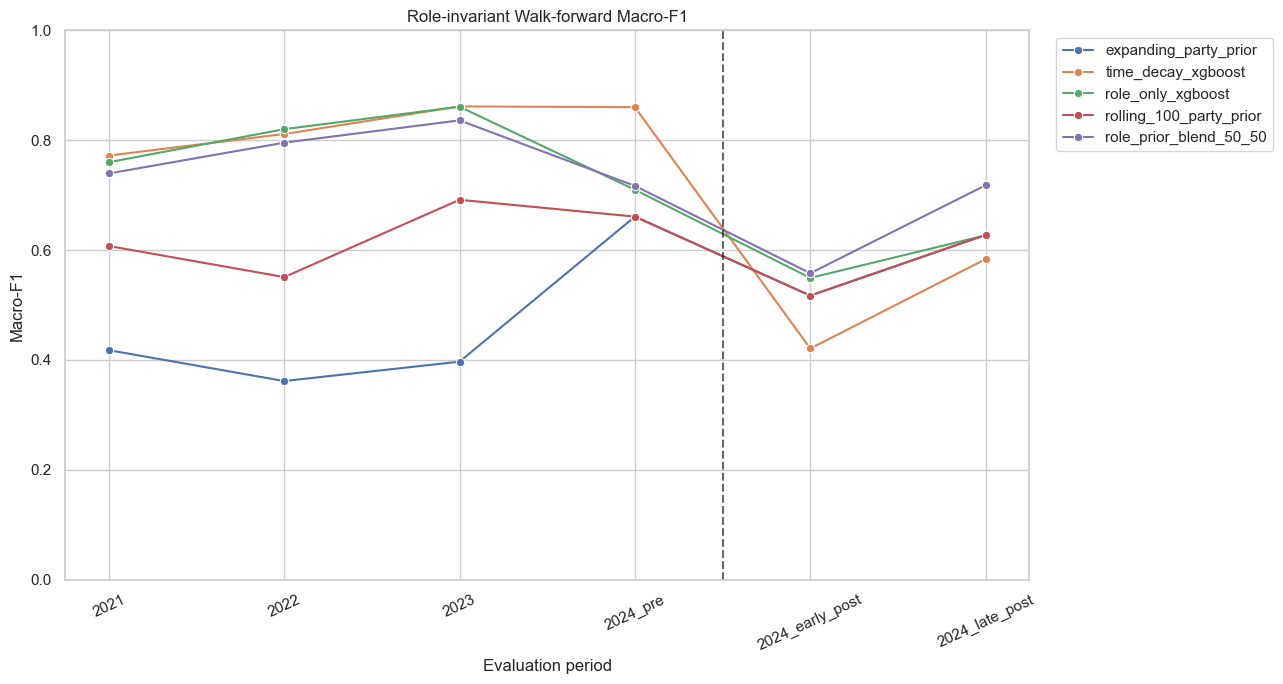

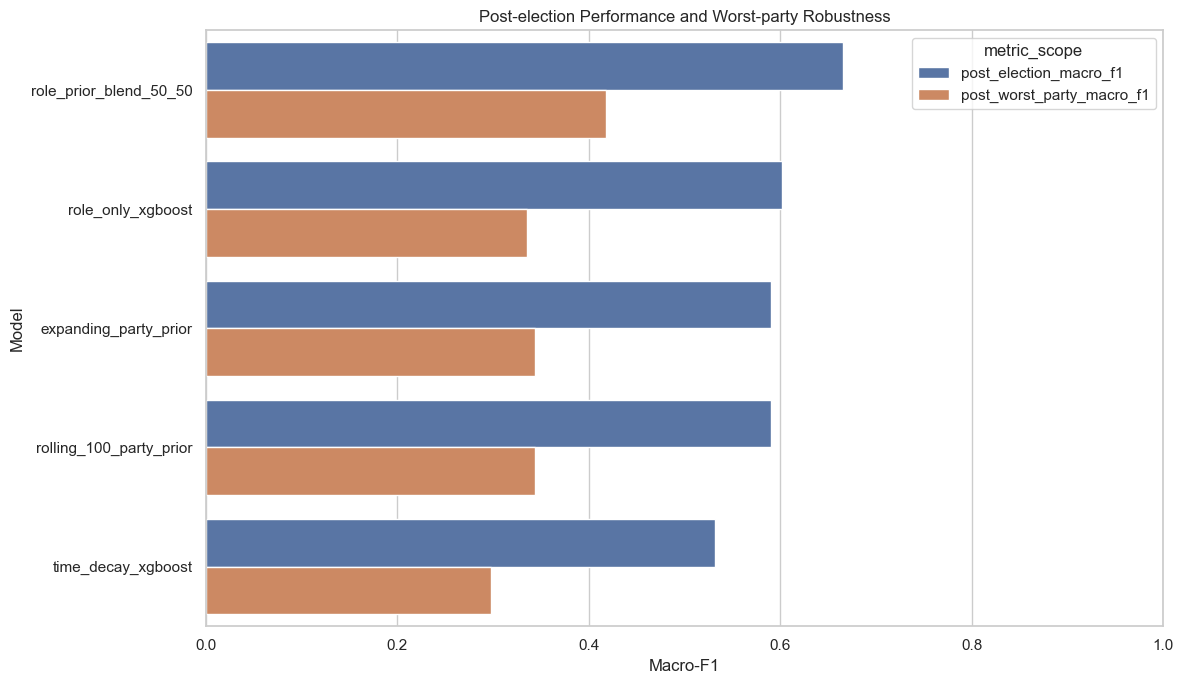

In [10]:
# 时间曲线可以直接看出模型在政府更替时是否崩溃
fold_order = [fold["fold"] for fold in FOLDS]
plot_frame = fold_metrics.copy()
plot_frame["fold"] = pd.Categorical(
    plot_frame["fold"], categories=fold_order, ordered=True
)

plt.figure(figsize=(13, 7))
sns.lineplot(
    data=plot_frame.sort_values("fold"),
    x="fold",
    y="macro_f1",
    hue="model",
    marker="o",
)
plt.axvline(3.5, color="black", linestyle="--", alpha=0.6)
plt.ylim(0, 1)
plt.title("Role-invariant Walk-forward Macro-F1")
plt.xlabel("Evaluation period")
plt.ylabel("Macro-F1")
plt.xticks(rotation=25)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "role_model_walk_forward_v2.png", dpi=160)
plt.show()

post_plot = model_comparison[[
    "model",
    "post_election_macro_f1",
    "post_worst_party_macro_f1",
]].melt(
    id_vars="model",
    var_name="metric_scope",
    value_name="metric_value",
)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=post_plot,
    y="model",
    x="metric_value",
    hue="metric_scope",
)
plt.xlim(0, 1)
plt.title("Post-election Performance and Worst-party Robustness")
plt.xlabel("Macro-F1")
plt.ylabel("Model")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "role_model_post_election_v2.png", dpi=160)
plt.show()


## 10. 输出审阅摘要

请把最后文本框完整复制回来。无论结果通过还是失败，09B之后都不再继续扩展开发模型：下一步是冻结架构并准备一次最终Test。


In [11]:
baseline_row = comparison_indexed.loc[BASELINE_MODEL]
candidate_row = comparison_indexed.loc[selected_candidate_name]

summary_lines = [
    "=== ROLE-INVARIANT MODEL SUMMARY FOR REVIEW ===",
    "Notebook version: 09b-role-invariant-xgboost-v2",
    "API calls: 0",
    "LLM calls: 0",
    "Test loaded: False",
    f"Development rows: {len(development)}",
    f"Development divisions: {development['division_key'].nunique()}",
    f"Selected candidate: {selected_candidate_name}",
    f"Candidate mean-fold Macro-F1: "
    f"{candidate_row['mean_fold_macro_f1']:.3f}",
    f"Candidate post-election Macro-F1: "
    f"{candidate_row['post_election_macro_f1']:.3f}",
    f"Candidate early-post Macro-F1: "
    f"{candidate_row['early_post_macro_f1']:.3f}",
    f"Candidate late-post Macro-F1: "
    f"{candidate_row['late_post_macro_f1']:.3f}",
    f"Candidate worst-fold Macro-F1: "
    f"{candidate_row['worst_fold_macro_f1']:.3f}",
    f"Candidate post-election worst-party Macro-F1: "
    f"{candidate_row['post_worst_party_macro_f1']:.3f}",
    f"Rolling-100 post-election Macro-F1: "
    f"{baseline_row['post_election_macro_f1']:.3f}",
    f"Rolling-100 post-election worst-party Macro-F1: "
    f"{baseline_row['post_worst_party_macro_f1']:.3f}",
    f"Acceptance gates: {acceptance_gates}",
    f"Candidate passes: {candidate_passes}",
    f"Recommended model: {recommended_model}",
    f"Next step: {next_step}",
    "Model comparison:",
    model_comparison[[
        "model",
        "mean_fold_macro_f1",
        "worst_fold_macro_f1",
        "post_election_macro_f1",
        "early_post_macro_f1",
        "late_post_macro_f1",
        "post_worst_party_macro_f1",
        "macro_f1",
        "accuracy",
        "roc_auc",
        "brier",
    ]].round(3).to_string(index=False),
    "RUN_FINAL_TEST: False",
    "Test result: NOT RUN",
    f"Output directory: {OUTPUT_DIR}",
    "=== END ROLE-INVARIANT MODEL SUMMARY ===",
]

summary_text = "\n".join(summary_lines)
print(summary_text)
(OUTPUT_DIR / "role_invariant_model_summary_v2.txt").write_text(
    summary_text, encoding="utf-8"
)


=== ROLE-INVARIANT MODEL SUMMARY FOR REVIEW ===
Notebook version: 09b-role-invariant-xgboost-v2
API calls: 0
LLM calls: 0
Test loaded: False
Development rows: 3392
Development divisions: 939
Selected candidate: role_prior_blend_50_50
Candidate mean-fold Macro-F1: 0.727
Candidate post-election Macro-F1: 0.665
Candidate early-post Macro-F1: 0.558
Candidate late-post Macro-F1: 0.718
Candidate worst-fold Macro-F1: 0.558
Candidate post-election worst-party Macro-F1: 0.418
Rolling-100 post-election Macro-F1: 0.591
Rolling-100 post-election worst-party Macro-F1: 0.344
Acceptance gates: {'post_election_improvement_gate': True, 'mean_fold_gate': True, 'worst_fold_gate': True, 'post_worst_party_gate': False}
Candidate passes: False
Recommended model: rolling_100_party_prior
Next step: Stop model tuning; freeze Rolling-100 Party Prior as the probability baseline and keep RAG as the explanation layer.
Model comparison:
                  model  mean_fold_macro_f1  worst_fold_macro_f1  post_election

2268